In [ ]:
pip install librosa numpy tqdm

In [1]:
import librosa
import numpy as np
from tqdm import tqdm
import pandas as pd

In [2]:
df = pd.read_csv("../dataset_metadata.csv")
df.head()

,path,emotion,actor
0,../dataset\Actor_01\03-01-01-01-01-01-01.wav,neutral,Actor_01
1,../dataset\Actor_01\03-01-01-01-01-02-01.wav,neutral,Actor_01
2,../dataset\Actor_01\03-01-01-01-02-01-01.wav,neutral,Actor_01
3,../dataset\Actor_01\03-01-01-01-02-02-01.wav,neutral,Actor_01
4,../dataset\Actor_01\03-01-02-01-01-01-01.wav,calm,Actor_01


In [3]:
def extract_features(file_path):
    try:
        audio, sample_rate = librosa.load(file_path, duration=3, offset=0.5)
        #MFCC
        mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        mfcc_mean = np.mean(mfcc.T, axis=0)
        #Chroma
        chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
        chroma_mean = np.mean(chroma.T, axis=0)
        #Mel Spectrogram
        mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
        mel_mean = np.mean(mel.T, axis=0)
        #Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(audio)
        zcr_mean = np.mean(zcr)
        #RMS Energy
        rms = librosa.feature.rms(y=audio)
        rms_mean = np.mean(rms)
        #Combine All features
        features = np.hstack((
            mfcc_mean,
            chroma_mean,
           # mel_mean,
            zcr_mean,
            rms_mean
        ))
        return features
    except Exception as e:
        print("Error in processing file:", file_path)
        return None

In [4]:
X = []
y= []

for index, row in tqdm(df.iterrows(), total=len(df)):
    features = extract_features(row["path"])
    if features is not None:
        X.append(features)
        y.append(row["emotion"])

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Labels shape:",y.shape)

  0%|                                                  | 0/1440 [00:00<?, ?it/s]C:\ddata\git program\speech-emotion-recognition\ser_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|███████████████████████████████████████| 1440/1440 [02:48<00:00,  8.53it/s]

Feature shape: (1440, 54)
Labels shape: (1440,)


In [5]:
#Encoding
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [6]:
#Train Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded,test_size=0.2,random_state=42, stratify=y_encoded)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1152, 54)
Test shape: (288, 54)


In [7]:
#Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', C=50, gamma='scale')
svm_model.fit(X_train, y_train)
print("SVM training complete")

SVM training complete


In [9]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.71875
Classification Report:

              precision    recall  f1-score   support

       angry       0.88      0.76      0.82        38
        calm       0.70      0.82      0.76        38
     disgust       0.68      0.74      0.71        38
     fearful       0.71      0.87      0.78        39
       happy       0.67      0.56      0.61        39
     neutral       0.75      0.63      0.69        19
         sad       0.63      0.58      0.60        38
   surprised       0.76      0.74      0.75        39

    accuracy                           0.72       288
   macro avg       0.72      0.71      0.71       288
weighted avg       0.72      0.72      0.72       288



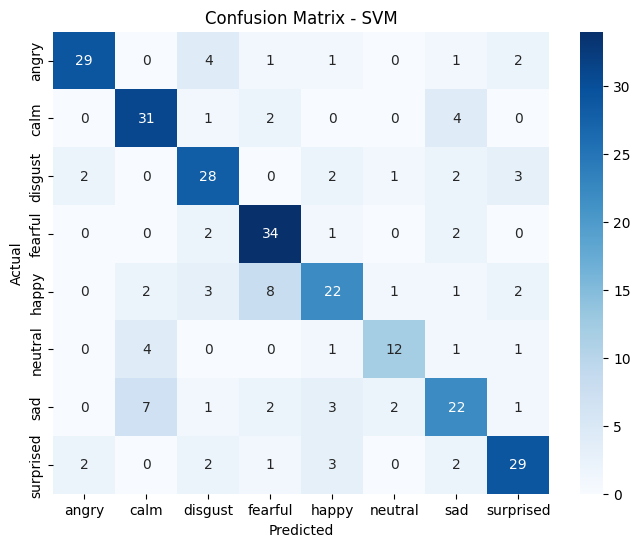

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
           xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap="Blues"
           )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

In [13]:
y_pred_svm = svm_model.predict(X_test)
y_true_svm = y_test

In [15]:
emotion_labels = label_encoder.classes_
svm_report_dict = classification_report(
    y_true_svm,
    y_pred_svm,
    target_names=emotion_labels,
    output_dict=True
)

svm_report_df = pd.DataFrame(svm_report_dict).transpose()
svm_report_df["Model"] = "SVM"

svm_report_df.head()

,precision,recall,f1-score,support,Model
angry,0.878788,0.763158,0.816901,38.0,SVM
calm,0.704545,0.815789,0.756098,38.0,SVM
disgust,0.682927,0.736842,0.708861,38.0,SVM
fearful,0.708333,0.871795,0.781609,39.0,SVM
happy,0.666667,0.564103,0.611111,39.0,SVM


In [16]:
cm_svm = confusion_matrix(y_true_svm, y_pred_svm)

cm_svm_data = []

for i, actual in enumerate(emotion_labels):
    for j, predicted in enumerate(emotion_labels):
        cm_svm_data.append([
            actual,
            predicted,
            cm_svm[i, j],
            "SVM"
        ])

svm_cm_df = pd.DataFrame(
    cm_svm_data,
    columns=["Actual", "Predicted", "Count", "Model"]
)

svm_cm_df.head()

,Actual,Predicted,Count,Model
0,angry,angry,29,SVM
1,angry,calm,0,SVM
2,angry,disgust,4,SVM
3,angry,fearful,1,SVM
4,angry,happy,1,SVM


In [17]:
svm_accuracy = np.mean(y_pred_svm == y_true_svm)

svm_accuracy_df = pd.DataFrame({
    "Model": ["SVM"],
    "Accuracy": [svm_accuracy]
})

svm_accuracy_df

,Model,Accuracy
0,SVM,0.71875


In [18]:
# Load existing CNN CSVs
cnn_report_df = pd.read_csv("cnn_classification_report.csv")
cnn_cm_df = pd.read_csv("cnn_confusion_matrix.csv")
accuracy_df = pd.read_csv("model_accuracy.csv")

# Combine classification reports
combined_report = pd.concat([cnn_report_df, svm_report_df])
combined_report.to_csv("combined_classification_report.csv")

# Combine confusion matrices
combined_cm = pd.concat([cnn_cm_df, svm_cm_df])
combined_cm.to_csv("combined_confusion_matrix.csv", index=False)

# Combine accuracies
combined_accuracy = pd.concat([accuracy_df, svm_accuracy_df])
combined_accuracy.to_csv("combined_model_accuracy.csv", index=False)